<a href="https://colab.research.google.com/github/ajmalbiju56/ML/blob/main/big_mart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 1.7 MB/s eta 0:00:00


In [ ]:
#libaries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/train_v9rqX0R.csv")
print(df)

     Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0              FDA15        9.300          Low Fat         0.016047   
1              DRC01        5.920          Regular         0.019278   
2              FDN15       17.500          Low Fat         0.016760   
3              FDX07       19.200          Regular         0.000000   
4              NCD19        8.930          Low Fat         0.000000   
...              ...          ...              ...              ...   
8518           FDF22        6.865          Low Fat         0.056783   
8519           FDS36        8.380          Regular         0.046982   
8520           NCJ29       10.600          Low Fat         0.035186   
8521           FDN46        7.210          Regular         0.145221   
8522           DRG01       14.800          Low Fat         0.044878   

                  Item_Type  Item_MRP Outlet_Identifier  \
0                     Dairy  249.8092            OUT049   
1               Soft Drinks  

# Data PreProcessing

* eda(explotaory data analysis)
* feature engineering
* model Building
* performance validation


In [ ]:
df.shape

(8523, 12)

In [ ]:
df.head(10)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [ ]:
#metadates of the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


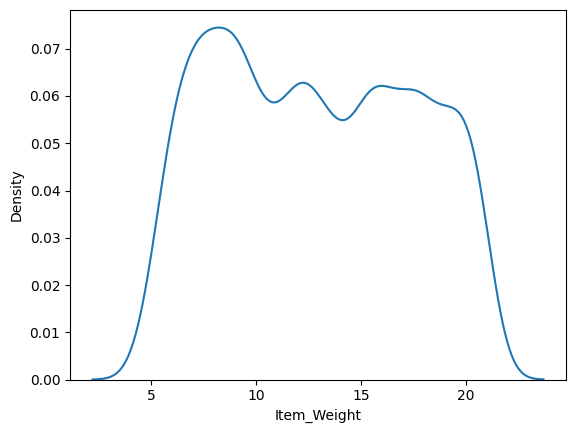

In [ ]:
sns.kdeplot(df['Item_Weight'])
plt.show()

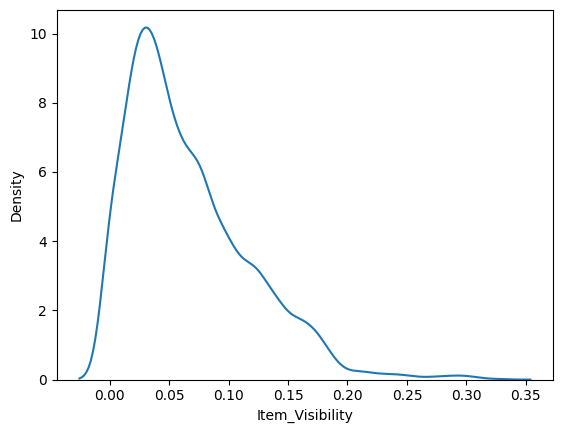

In [ ]:
sns.kdeplot(df['Item_Visibility'])
plt.show()

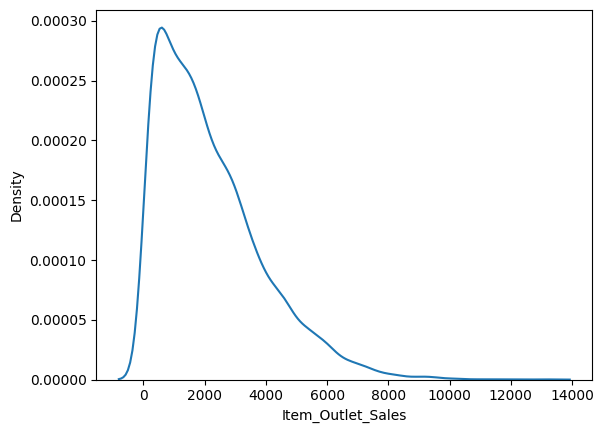

In [ ]:
sns.kdeplot(df['Item_Outlet_Sales'])
plt.show()

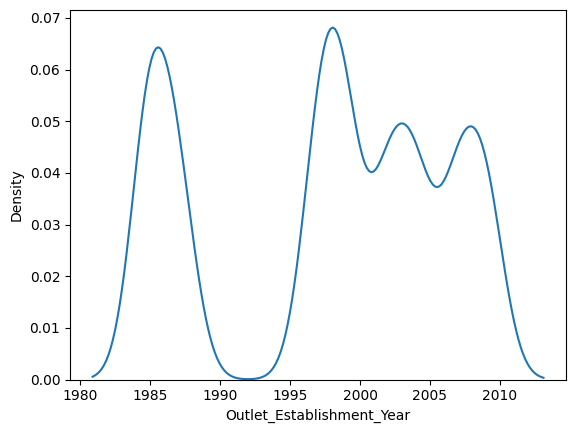

In [ ]:
sns.kdeplot(df['Outlet_Establishment_Year'])
plt.show()

#univariate analysis

In [ ]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


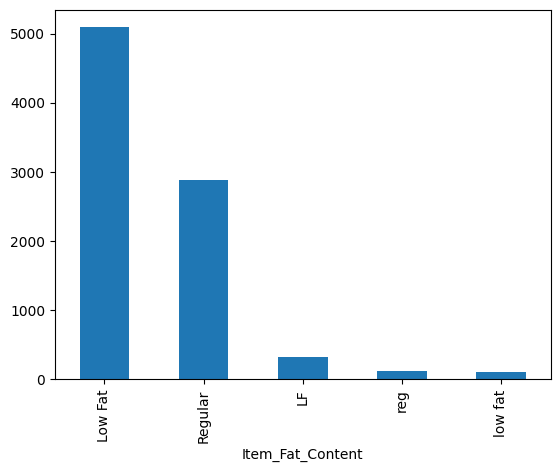

In [ ]:
df['Item_Fat_Content'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
num= df.select_dtypes(include=np.number)
num.columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
cat = df.select_dtypes(include=object)
cat.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

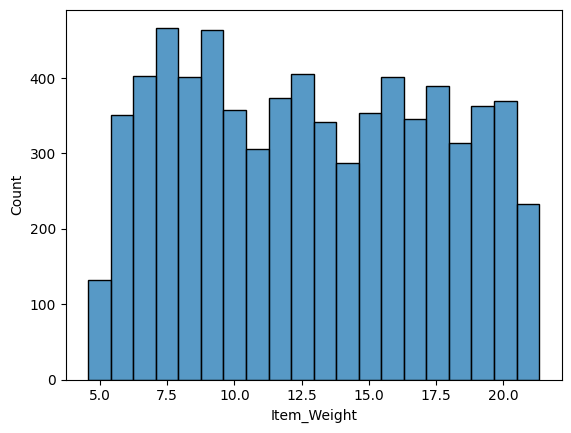

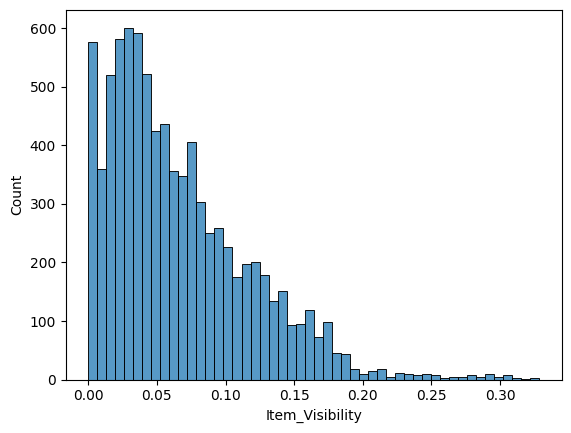

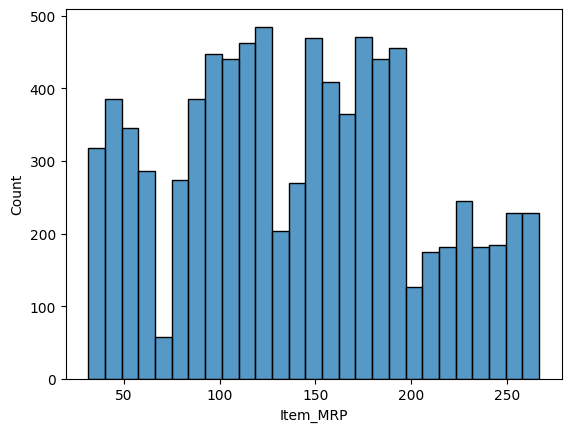

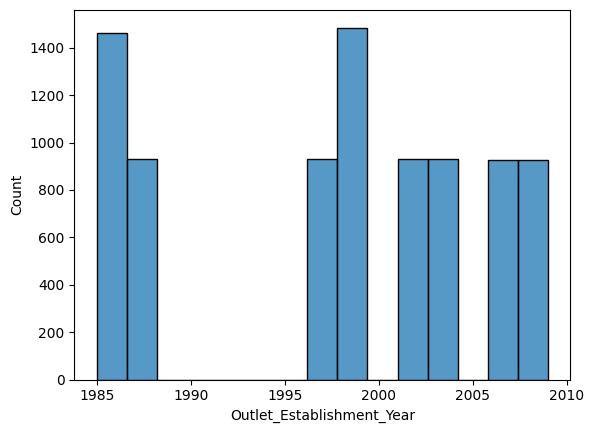

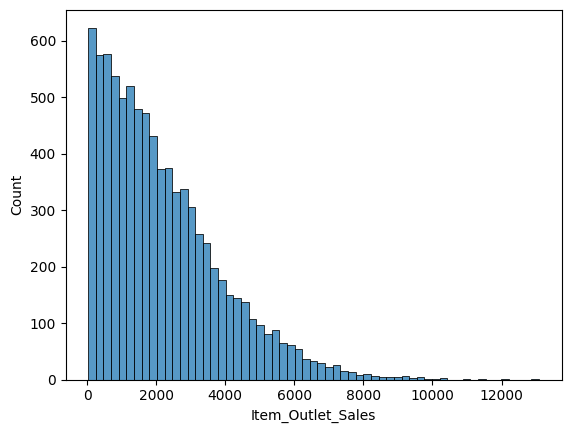

In [ ]:
# for numerical features
for i in num.columns:
  sns.histplot(df[i])
  plt.show()

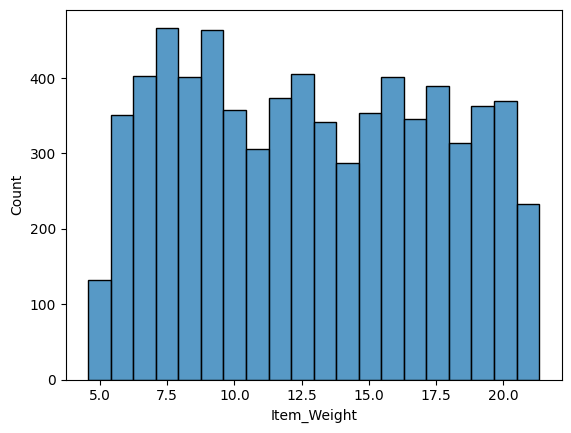

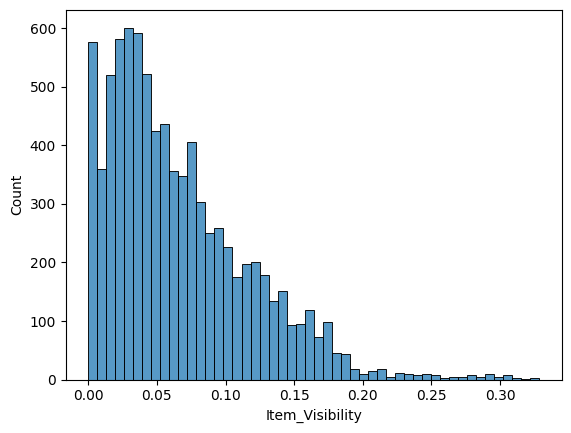

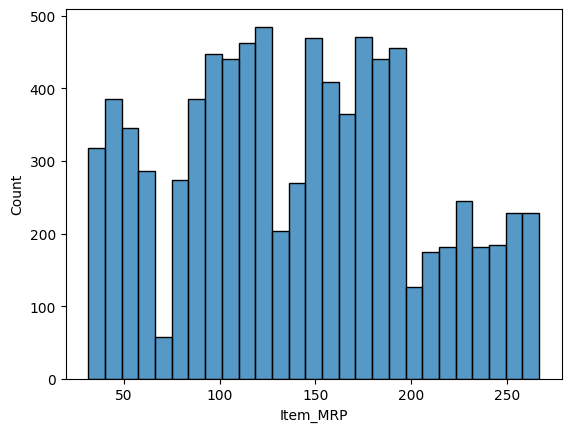

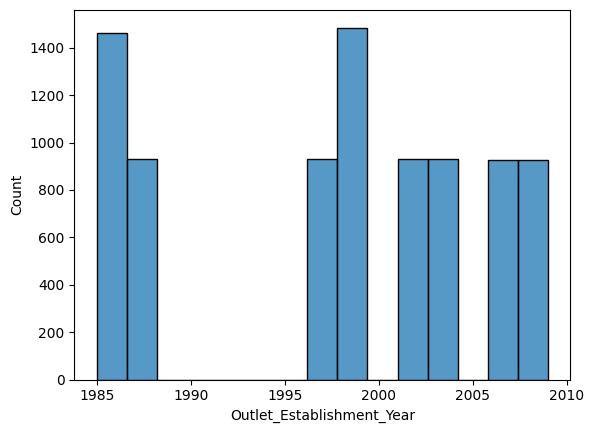

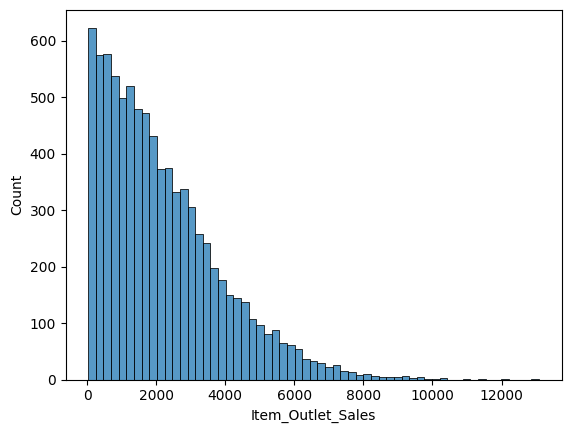

In [ ]:
for i in num.columns:
  sns.histplot(df[i])
  plt.show()

# bivariate analysis

<function matplotlib.pyplot.show(close=None, block=None)>

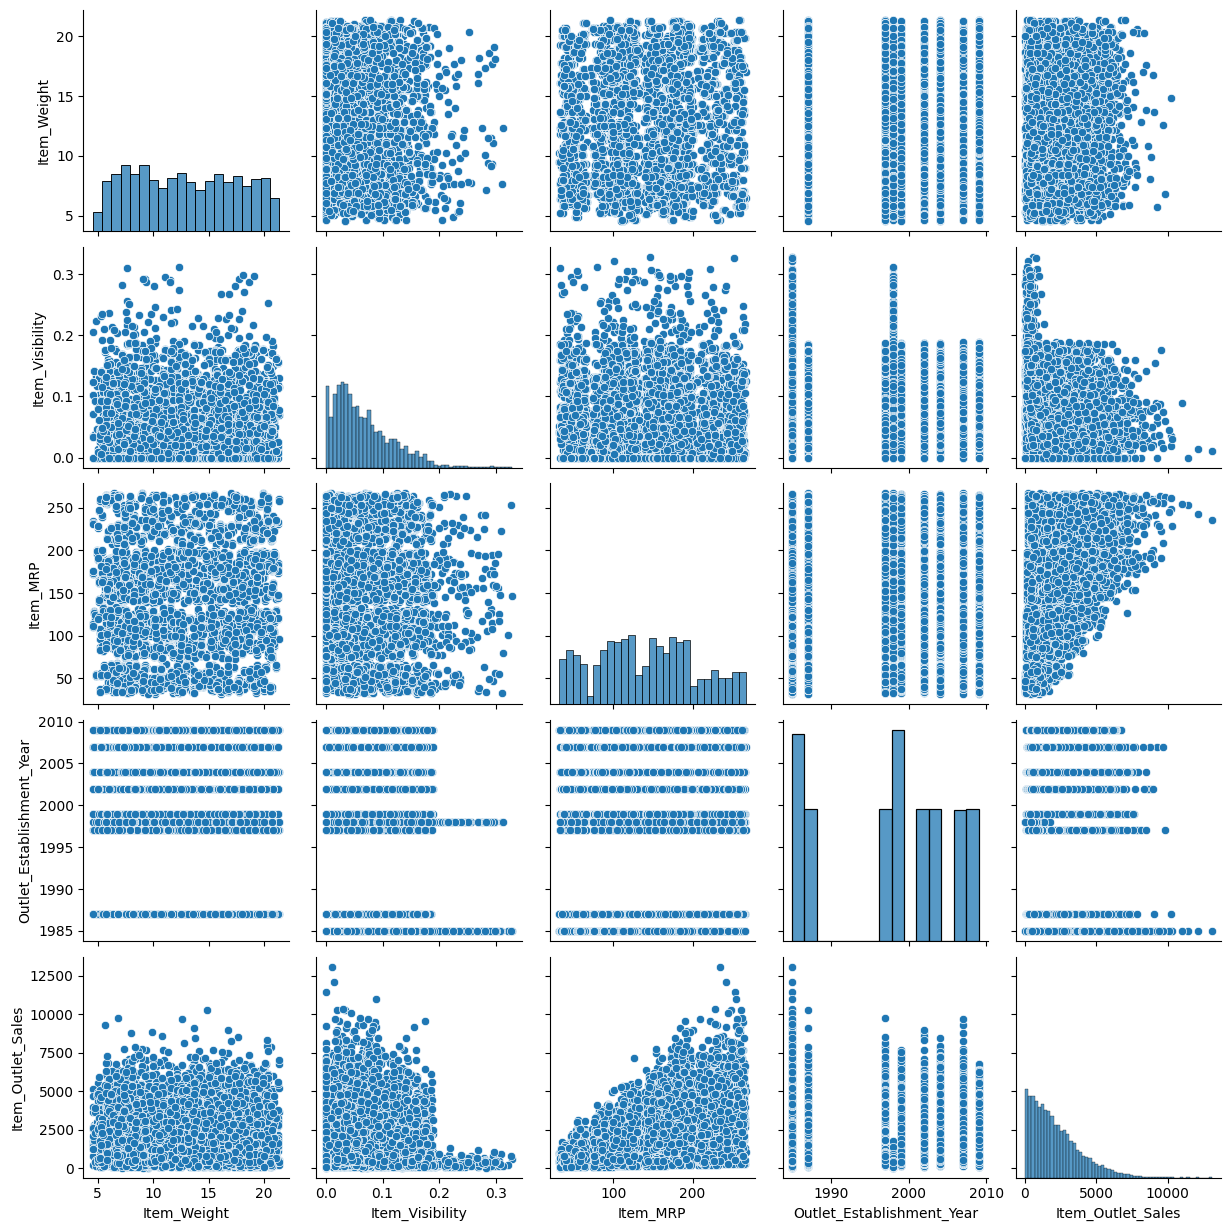

In [ ]:
sns.pairplot(df)
plt.show

# multivariate analysis

In [ ]:
#multivarient for numerical hue as make
num=df.select_dtypes(include=np.number)
num.columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


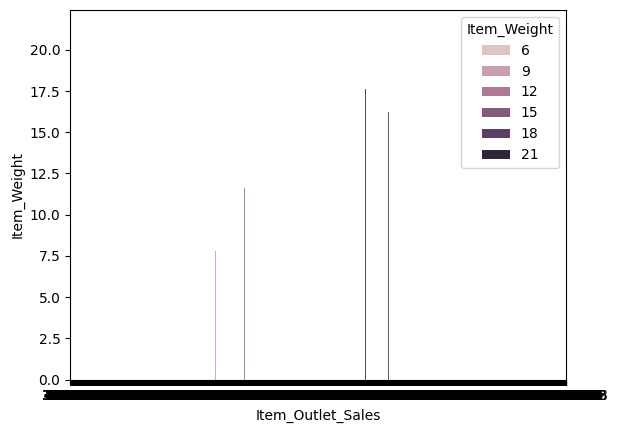

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


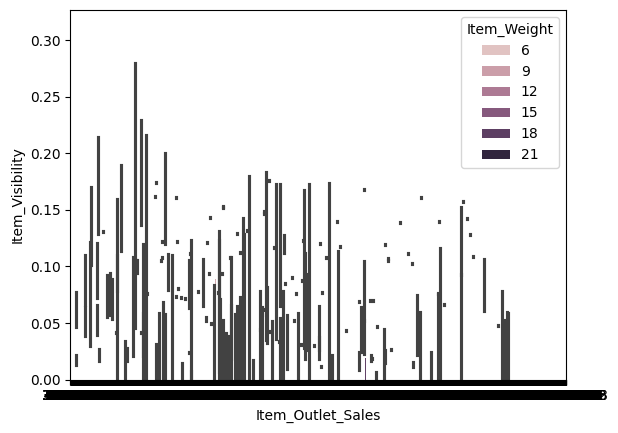

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


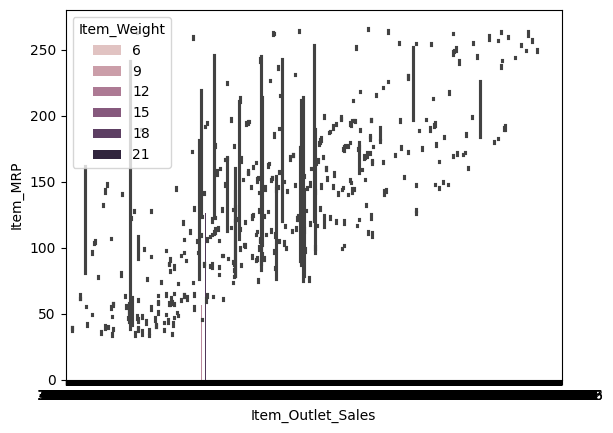

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


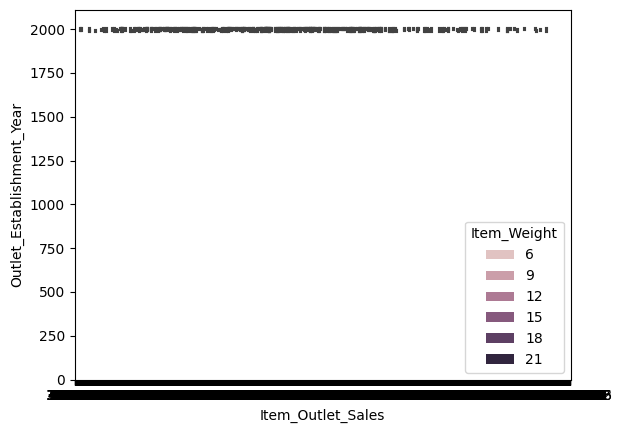

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


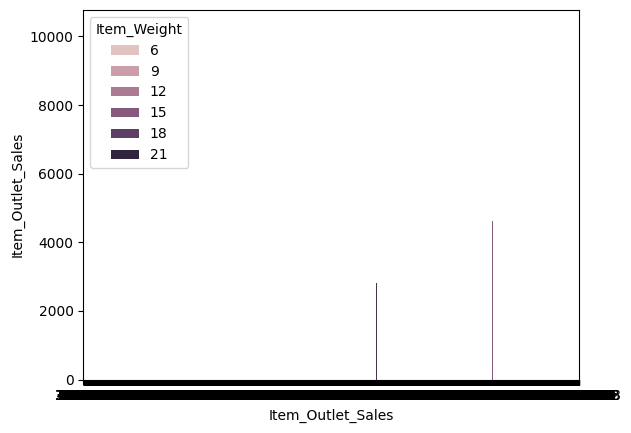

In [ ]:
num=df.select_dtypes(include=['number']).columns.tolist()
for i in num:
  sns.barplot(x=df['Item_Outlet_Sales'],y=df[i],hue=df['Item_Weight'])
  plt.show()

# feature engineering

In [ ]:
# Step 1: Handle missing values
df['Item_MRP'].fillna(df['Item_MRP'].mean(), inplace=True)
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)

<ipython-input-26-1569043366>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_MRP'].fillna(df['Item_MRP'].mean(), inplace=True)
<ipython-input-26-1569043366>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
df['Item_Weight'].fillna(df['Item_Weight'].mode()[0], inplace=True)

<ipython-input-27-2190086711>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [ ]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [ ]:
df['Item_fat_content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

In [ ]:
df['Item_Fat_Content'].value_counts(dropna=False)


,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [ ]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

In [ ]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


# label encoding


In [ ]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_fat_content
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,Low Fat
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,Regular
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,Low Fat
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,Regular
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,Low Fat
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,Low Fat
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850,Regular
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136,Low Fat
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976,Regular


In [ ]:
from category_encoders import TargetEncoder

Ib_enginelocation = LabelEncoder()
df['Item_Fat_Content'] = Ib_enginelocation.fit_transform(df['Item_Fat_Content'])

In [ ]:
from category_encoders import TargetEncoder

Ib_enginelocation = LabelEncoder()
df['Outlet_Type'] = Ib_enginelocation.fit_transform(df['Outlet_Type'])

In [ ]:
from category_encoders import TargetEncoder

Ib_enginelocation = LabelEncoder()
df['Outlet_Size'] = Ib_enginelocation.fit_transform(df['Outlet_Size'])

In [ ]:
from category_encoders import TargetEncoder

Ib_enginelocation = LabelEncoder()
df['Outlet_Location_Type'] = Ib_enginelocation.fit_transform(df['Outlet_Location_Type'])

# target encoding

In [ ]:
tb_Item_Identifier= TargetEncoder(cols=['Item_Identifier'])
df['Item_Identifier'] = tb_Item_Identifier.fit_transform(df['Item_Identifier'],df['Item_Outlet_Sales'])

In [ ]:
tb_Outlet_Identifier= TargetEncoder(cols=['Outlet_Identifier'])
df['Outlet_Identifier'] = tb_Outlet_Identifier.fit_transform(df['Outlet_Identifier'],df['Item_Outlet_Sales'])

In [ ]:
tb_Item_Type= TargetEncoder(cols=['Item_Type'])
df['Item_Type'] = tb_Item_Type.fit_transform(df['Item_Type'],df['Item_Outlet_Sales'])

In [ ]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_fat_content
0,2879.598286,9.300,0,0.016047,2232.542597,249.8092,2348.354635,1999,1,0,1,3735.1380,Low Fat
1,1920.354050,5.920,1,0.019278,2006.511735,48.2692,1995.498739,2009,1,2,2,443.4228,Regular
2,2030.685308,17.500,0,0.016760,2158.977911,141.6180,2348.354635,1999,1,0,1,2097.2700,Low Fat
3,2347.410648,19.200,1,0.000000,2289.009592,182.0950,339.351662,1998,1,2,0,732.3800,Regular
4,1879.152033,8.930,0,0.000000,2258.784300,53.8614,2298.995256,1987,0,2,1,994.7052,Low Fat
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,2424.628001,6.865,0,0.056783,2277.321739,214.5218,2298.995256,1987,0,2,1,2778.3834,Low Fat
8519,2271.350452,8.380,1,0.046982,1952.971207,108.1570,2192.384798,2002,1,1,1,549.2850,Regular
8520,1991.431370,10.600,0,0.035186,2010.000265,85.1224,2438.841866,2004,2,1,1,1193.1136,Low Fat
8521,2158.829654,7.210,1,0.145221,2277.321739,103.1332,1995.498739,2009,1,2,2,1845.5976,Regular


# handling outlayers

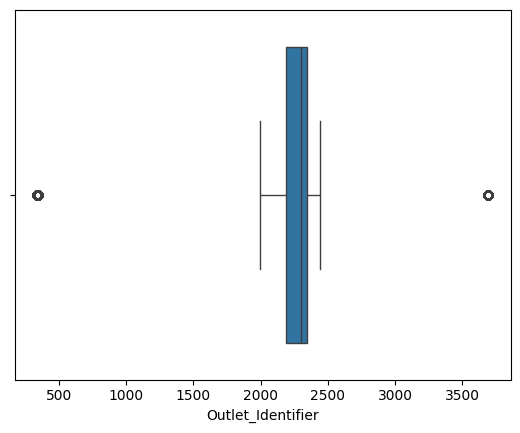

In [ ]:
sns.boxplot(df['Outlet_Identifier'],orient='h')
plt.show()

In [ ]:
q1 =np.quantile(df['Outlet_Identifier'],0.25)
q3 =np.quantile(df['Outlet_Identifier'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True,inplace=True)
for i in range(len(df)):
   if df.loc[i, 'Outlet_Identifier'] > max_bound:
        df.loc[i, 'Outlet_Identifier'] = max_bound

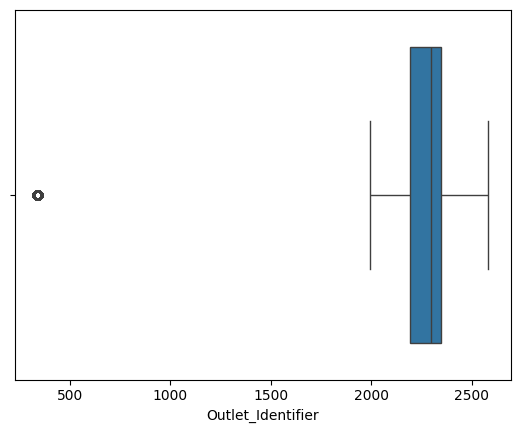

In [ ]:
sns.boxplot(df['Outlet_Identifier'],orient='h')
plt.show()

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

In [ ]:
df = remove_outliers_iqr(df, 'Item_Visibility')
df = remove_outliers_iqr(df, 'Item_MRP')
df = remove_outliers_iqr(df, 'Item_Outlet_Sales')

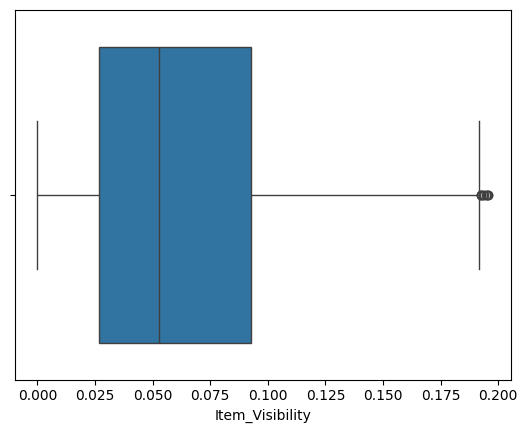

In [ ]:
sns.boxplot(df['Item_Visibility'],orient='h')
plt.show()

# checking for corelation

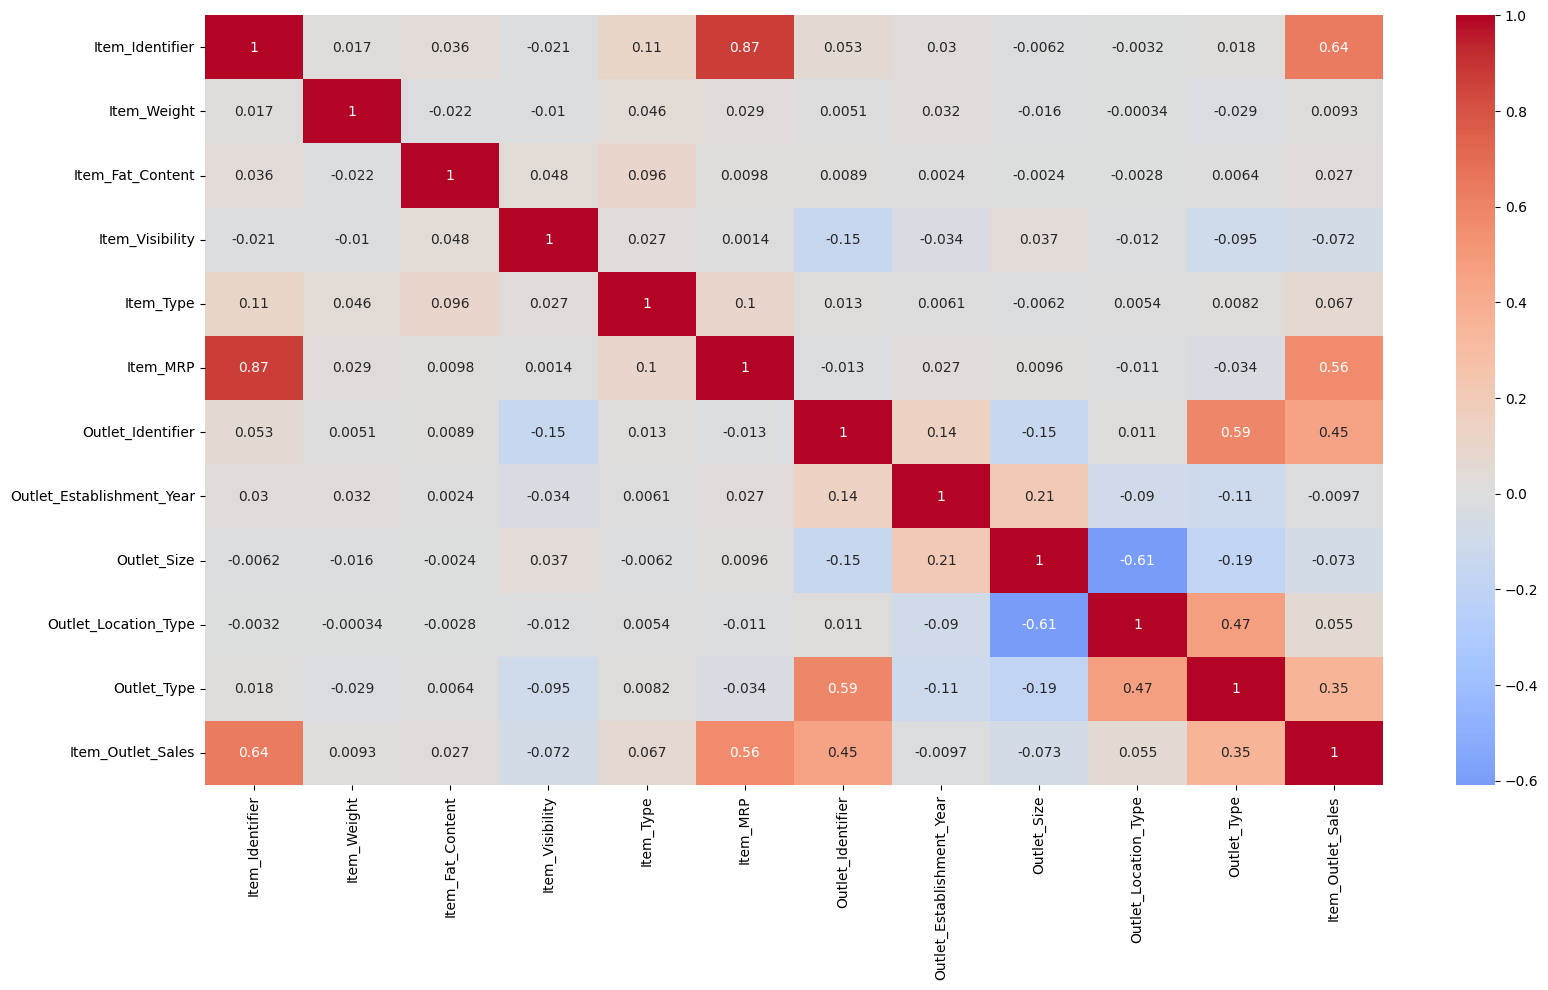

In [ ]:
# Now calculate and plot the correlation matrix
plt.figure(figsize=(19,10))
# Select only numeric columns before calculating the correlation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True,cmap="coolwarm",center=0)
plt.show()

In [ ]:
#picking coloumns from highest corelation
df_new = df[['Item_Outlet_Sales','Item_Identifier','Item_MRP','Outlet_Identifier']]

# multicorelation

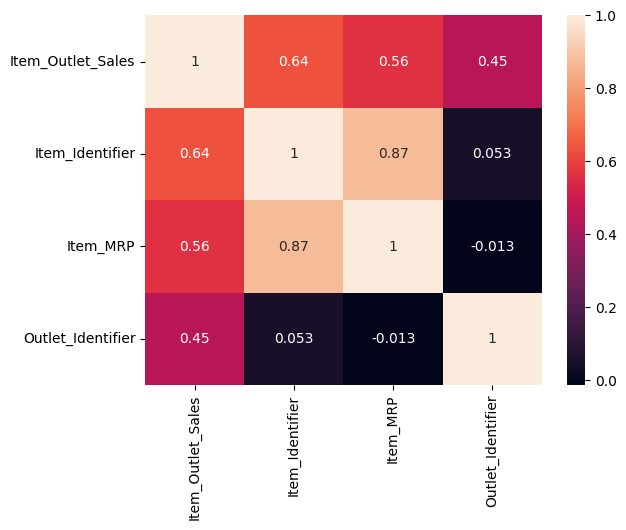

In [ ]:
sns.heatmap(df_new.corr(),annot=True)
plt.show()

# data scailing

In [ ]:
df_new = df[['Item_Outlet_Sales','Item_Identifier','Item_MRP','Outlet_Identifier']]

In [ ]:
df_new_encoded = df_new.copy()
le = LabelEncoder()

# Encode categorical features
df_new_encoded['Item_Identifier'] = le.fit_transform(df_new_encoded['Item_Identifier'])
df_new_encoded['Outlet_Identifier'] = le.fit_transform(df_new_encoded['Outlet_Identifier'])

In [ ]:
scaler = StandardScaler()
df_new_encoded['Item_MRP'] = scaler.fit_transform(df_new_encoded[['Item_MRP']])

# model building

In [ ]:
df_new = df[['Item_Outlet_Sales','Item_Identifier','Item_MRP','Outlet_Identifier']]

In [ ]:
df_new

,Item_Outlet_Sales,Item_Identifier,Item_MRP,Outlet_Identifier
0,3735.1380,2879.598286,249.8092,2348.354635
1,443.4228,1920.354050,48.2692,1995.498739
2,2097.2700,2030.685308,141.6180,2348.354635
3,732.3800,2347.410648,182.0950,339.351662
4,994.7052,1879.152033,53.8614,2298.995256
...,...,...,...,...
8518,2778.3834,2424.628001,214.5218,2298.995256
8519,549.2850,2271.350452,108.1570,2192.384798
8520,1193.1136,1991.431370,85.1224,2438.841866
8521,1845.5976,2158.829654,103.1332,1995.498739


In [ ]:
x=df_new.drop('Item_Outlet_Sales',axis=1)
y=df_new['Item_Outlet_Sales']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train

,Item_Identifier,Item_MRP,Outlet_Identifier
1766,2278.835741,207.0954,2277.844267
8196,2225.714335,198.5426,2192.384798
6669,2122.610513,126.4994,2438.841866
5132,1935.108552,62.6168,2298.995256
4439,1930.852798,43.5744,2192.384798
...,...,...,...
5437,1888.856068,42.4454,2582.309390
5608,2227.342777,196.1452,2348.354635
896,2311.226580,178.4370,2192.384798
7911,2156.409890,121.8072,2348.354635


In [ ]:
y_train

,Item_Outlet_Sales
1766,3125.9310
8196,1186.4556
6669,1670.4922
5132,639.1680
4439,407.4696
...,...
5437,293.6178
5608,1565.9616
896,1058.6220
7911,2450.1440


In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6554, 3)
(1639, 3)
(6554,)
(1639,)


# knn

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsRegressor()

In [ ]:
knn.score(x_train,y_train)

0.7133457377818159

In [ ]:
knn.score(x_test,y_test)

0.5921755217346203

In [ ]:
y_pred=knn.predict(x_test)
y_pred

array([2321.77776, 3419.41564, 2676.11652, ..., 1557.3062 , 2147.73764,
       3864.56952])

In [ ]:
result=pd.DataFrame({'actual':y_test,'predicted':y_pred})
result

,actual,predicted
5904,517.9924,2321.77776
6009,2241.0828,3419.41564
2202,755.6830,2676.11652
6927,2209.1244,3674.55020
5439,1581.9408,695.76100
...,...,...
2449,93.2120,247.94392
8110,49.2692,172.04272
7246,1842.9344,1557.30620
87,3285.7230,2147.73764


In [ ]:
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

In [ ]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 950605.1167597484
R² Score: 0.5921755217346203


# linear regression

In [ ]:
linearmodel=LinearRegression()
linearmodel.fit(x_train,y_train)

LinearRegression()

In [ ]:
linearmodel.score(x_train,y_train)

0.5795154176247146

In [ ]:
linearmodel.score(x_test,y_test)

0.5841995790505936

In [ ]:
print("Intercept:", linearmodel.intercept_)
print("Slope(s):", linearmodel.coef_)

Intercept: -7658.100816901139
Slope(s): [3.28526795 4.00709744 0.98478874]


# decision tree

In [ ]:
dec = DecisionTreeRegressor(random_state = 0)

In [ ]:
dec.fit(x_train, y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
dec.score(x_train,y_train)

1.0

In [ ]:
dec.score(x_test,y_test)

0.21642951833662394

In [ ]:
y_pred = dec.predict(x_test)

In [ ]:
rmse = float(format(np.sqrt(mean_squared_error(y_test, y_pred)), '.3f'))
print("\nRMSE: ", rmse)


RMSE:  1351.458


In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: 0.21642951833662394
Mean Squared Error: 1826437.9626727712
